# Число машин и ремонтников в системе Росса

Выполняется факторный план по числу рабочих машин и ремонтников. Для каждого
сочетания имитационная оценка сопоставляется с решением линейной системы CTMC.

In [1]:
using DrWatson
@quickactivate "EventSystemsStudy"
ENV["GKSwstype"] = "100"
include(srcdir("EventSystemsStudy.jl"))
using .EventSystemsStudy.RepairReserve, .EventSystemsStudy.EvidenceIO
using DataFrames, Statistics, Plots

## Факторный план

In [2]:
machine_counts = [8, 12, 20]
repairer_counts = [1, 2, 3]
replications = 40
comparisons = NamedTuple[]
replicate_rows = NamedTuple[]

for (case, (required, repairers)) in enumerate(Iterators.product(machine_counts, repairer_counts))
    for replicate in 1:replications
        result = run_reserve(; required, spares=3, repairers,
            failure_mean=100.0, repair_mean=1.0,
            seed=70_000+1_000case+replicate)
        s = result.summary
        push!(replicate_rows, (; case, replicate, required, repairers,
            failure_time=s.failure_time, busy_area=s.utilization*repairers*s.failure_time,
            capacity_time=repairers*s.failure_time, queue_area=s.mean_queue*s.failure_time))
    end
    sample = DataFrame(filter(row -> row.case == case, replicate_rows))
    estimate = summarize_replications(sample)
    exact = reserve_theory(; required, spares=3, repairers,
        failure_mean=100.0, repair_mean=1.0)
    push!(comparisons, (; case, required, spares=3, repairers,
        replications, simulated_time=estimate.mean_time,
        standard_error=estimate.standard_error, ci_low=estimate.ci_low,
        ci_high=estimate.ci_high, analytical_time=exact.mean_time,
        relative_error=abs(estimate.mean_time-exact.mean_time)/exact.mean_time,
        utilization=estimate.utilization, analytical_utilization=exact.utilization,
        mean_queue=estimate.mean_queue, analytical_queue=exact.mean_queue))
end
comparison = DataFrame(comparisons)
store_table("repair_capacity_study", "replications.csv", DataFrame(replicate_rows))
store_table("repair_capacity_study", "factorial_summary.csv", comparison)

"/workspace/labs/lab07/project/data/repair_capacity_study/factorial_summary.csv"

## Влияние ремонтной мощности

9×7 DataFrame
 Row │ required  repairers  simulated_time  analytical_time  relative_error  utilization  mean_queue
     │ Int64     Int64      Float64         Float64          Float64         Float64      Float64
─────┼────────────────────────────────────────────────────────────────────────────────────────────────
   1 │        8          1   19713.7          28839.1             0.316425     0.0798181  0.00671239
   2 │       12          1    7080.17          6221.6             0.137997     0.11902    0.0149092
   3 │       20          1    1011.86           970.0             0.0431579    0.199352   0.0405627
   4 │        8          2       1.28575e5        1.10206e5       0.166677     0.03984    0.000112168
   5 │       12          2   21663.0          23142.9             0.0639478    0.0600645  0.000334155
   6 │       20          2    4106.03          3395.0             0.209435     0.0996183  0.00146075
   7 │        8          3   99063.0              1.63097e5       0.392613    

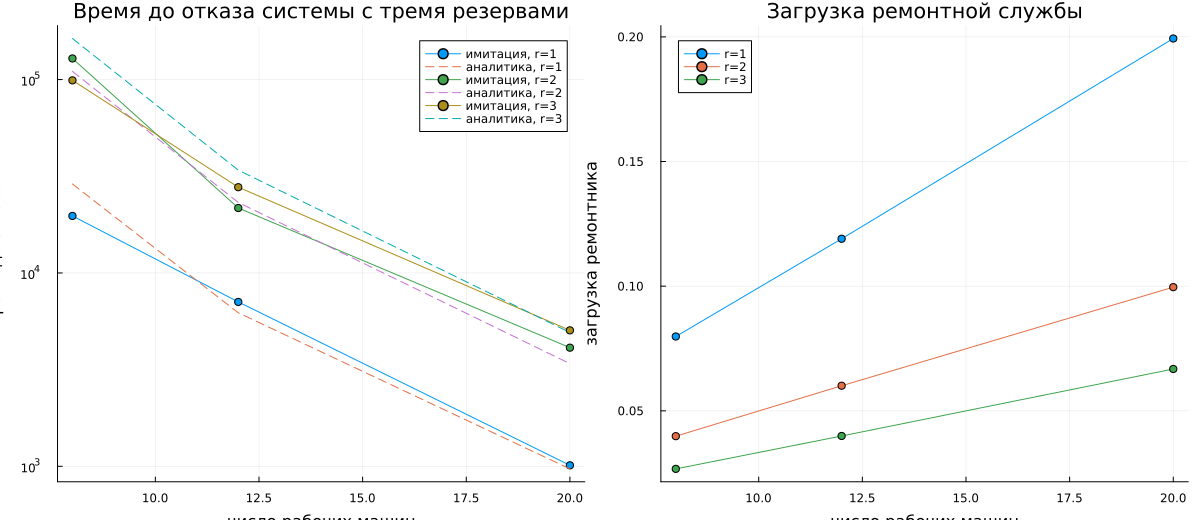

In [3]:
println(comparison[:, [:required, :repairers, :simulated_time,
    :analytical_time, :relative_error, :utilization, :mean_queue]])
p_time = plot(; xlabel="число рабочих машин", ylabel="время до отказа",
    yscale=:log10, title="Время до отказа системы с тремя резервами")
p_load = plot(; xlabel="число рабочих машин", ylabel="загрузка ремонтника",
    title="Загрузка ремонтной службы")
for repairers in repairer_counts
    rows = comparison[comparison.repairers .== repairers, :]
    plot!(p_time, rows.required, rows.simulated_time; marker=:circle,
        label="имитация, r=$repairers")
    plot!(p_time, rows.required, rows.analytical_time; linestyle=:dash,
        label="аналитика, r=$repairers")
    plot!(p_load, rows.required, rows.utilization; marker=:circle,
        label="r=$repairers")
end
figure = plot(p_time, p_load; layout=(1,2), size=(1200,520))
store_figure("repair_capacity_study", "capacity_comparison.png", figure)
figure

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*